# Data preparation

In [1]:
import os
import pandas as pd
from google.cloud import bigquery, storage
from google.colab import auth
# Set up environment and authenticate (if running on Colab or GCP)
auth.authenticate_user()
project_id = 'mcxrp-429811'
os.environ["GOOGLE_CLOUD_PROJECT"] = project_id
# !gcloud config set project {project_id}

# Initialize BigQuery and Storage clients
client = bigquery.Client(project=project_id)
storage_client = storage.Client(project=project_id)

# Bucket and data paths
bucket_name = 'cxr_embedding'
bucket = storage_client.bucket(bucket_name)
ards_data_path = 'ARDS cohort ~1000 patients 28 days July.csv'  # Update this path if necessary

# Download the ARDS cohort data file from the GCP bucket
ards_blob = bucket.blob(ards_data_path)
ards_blob.download_to_filename('/tmp/ards_data.csv')

# Load the ARDS cohort data into a DataFrame
ards_df = pd.read_csv('/tmp/ards_data.csv')

# Continue with the univariate analysis code...
# (The code for univariate analysis provided previously follows here)


<ipython-input-1-897df3276665>:25: DtypeWarning: Columns (41) have mixed types. Specify dtype option on import or set low_memory=False.
  ards_df = pd.read_csv('/tmp/ards_data.csv')


# Find significant features from clinical data + only include day zero rows

In [2]:
import pandas as pd
import statsmodels.api as sm
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold
from statsmodels.tools.sm_exceptions import PerfectSeparationError

# Load your data (assuming it's already loaded as ards_df)
# ards_df = pd.read_csv('/tmp/ards_data.csv')

# Step 1: Filter rows where 'days_from_start' is zero
ards_df = ards_df[ards_df['days_from_start'] == 0]

# Target variable
y = ards_df['icu_mort']

# Filter for numeric columns only (ignoring booleans, dates, etc.)
numeric_columns = ards_df.select_dtypes(include=['number']).columns
numeric_columns = numeric_columns.drop('icu_mort')  # Exclude the target variable if it's numeric

# Store significant results
significant_columns = []

# Initialize the standard scaler
scaler = StandardScaler()

# Initialize the variance threshold filter
var_thresh = VarianceThreshold(threshold=1e-4)

# Perform univariate logistic regression for each numeric column
for column in numeric_columns:
    X = ards_df[[column]]

    # Remove rows with NaN or infinite values
    X = X.replace([np.inf, -np.inf], np.nan).dropna()

    # Also remove corresponding rows from the target variable
    y_filtered = y[X.index]

    # Apply variance threshold to filter out low-variance columns
    if X.var().iloc[0] > 1e-4 and len(X) > 1:
        try:
            # Standardize the predictor only if there are valid rows
            X = pd.DataFrame(scaler.fit_transform(X), columns=[column], index=X.index)
            X = sm.add_constant(X)  # Add a constant term (intercept) to the model

            model = sm.Logit(y_filtered, X)
            result = model.fit(disp=0, maxiter=200)  # Increase max iterations
            p_value = result.pvalues.iloc[1]  # Access the p-value of the predictor coefficient by position using iloc
            coefficient = result.params.iloc[1]  # Access the coefficient of the predictor

            # Check if the p-value is less than 0.05
            if p_value < 0.05:
                significant_columns.append((column, coefficient, p_value))
        except (PerfectSeparationError, np.linalg.LinAlgError, ValueError) as e:
            print(f"Skipping column '{column}' due to convergence or data issues: {e}")
            continue

# Convert the significant columns into a DataFrame for better display
significant_df = pd.DataFrame(significant_columns, columns=['Column', 'Coefficient', 'P-value'])

# Display the significant columns with coefficients and p-values
print(significant_df)


                           Column  Coefficient       P-value
0        ards_onset_from_icuadmit     0.200961  2.538425e-03
1          death_after_ards_onset    -0.798968  9.976338e-07
2                   admission_age     0.389613  2.558056e-07
3                         los_icu    -0.307026  3.411970e-04
4                    los_hospital    -0.700536  3.576885e-09
..                            ...          ...           ...
68                 norad_vasorate     0.250599  1.339163e-04
69                   vaso_running     0.252804  2.160291e-04
70  avg_norepinephrine_equivalent     0.179191  6.136477e-03
71                vaso_running_ne     0.280321  1.765952e-04
72                 vent_free_days     0.192965  9.252094e-03

[73 rows x 3 columns]


/usr/local/lib/python3.10/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [3]:
from google.cloud import storage

# Set up the Google Cloud Storage client
storage_client = storage.Client()
bucket_name = 'cxr_embedding'
bucket = storage_client.bucket(bucket_name)

# Path to save the significant_df as a CSV in the bucket
file_name = 'ards_df.csv'
blob = bucket.blob(file_name)

# Save the significant_df DataFrame as a CSV to the Google Cloud Storage bucket
ards_df.to_csv('/tmp/ards_df.csv', index=False)
blob.upload_from_filename('/tmp/ards_df.csv')

print(f"Data saved to bucket '{bucket_name}' as '{file_name}'.")

Data saved to bucket 'cxr_embedding' as 'ards_df.csv'.


In [4]:
from google.cloud import storage

# Set up the Google Cloud Storage client
storage_client = storage.Client()
bucket_name = 'cxr_embedding'
bucket = storage_client.bucket(bucket_name)

# Path to save the significant_df as a CSV in the bucket
file_name = 'significant_df.csv'
blob = bucket.blob(file_name)

# Save the significant_df DataFrame as a CSV to the Google Cloud Storage bucket
significant_df.to_csv('/tmp/significant_df.csv', index=False)
blob.upload_from_filename('/tmp/significant_df.csv')

print(f"Data saved to bucket '{bucket_name}' as '{file_name}'.")

Data saved to bucket 'cxr_embedding' as 'significant_df.csv'.


In [5]:
# Extract the column names from the significant_df dataframe
significant_column_names = significant_df['Column'].tolist()

# Include the target variable 'icu_mort' as well
significant_column_names.append('icu_mort')

# Display the number of significant columns
print(f"Number of significant columns: {len(significant_column_names)}")
# Filter the dataset to include only the significant columns
ards_df_significant = ards_df[significant_column_names]


Number of significant columns: 74


# Filter out inappropriate features and undergo AUROC using XG boost (without filtering out covariance features)

<ipython-input-6-c76e0ef7eb2c>:42: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ards_df_filtered['final_avg_mbp'] = ards_df_filtered['avg_mbp'].combine_first(ards_df_filtered['avg_mbp_ni'])


Test AUROC: 0.8698275862068966


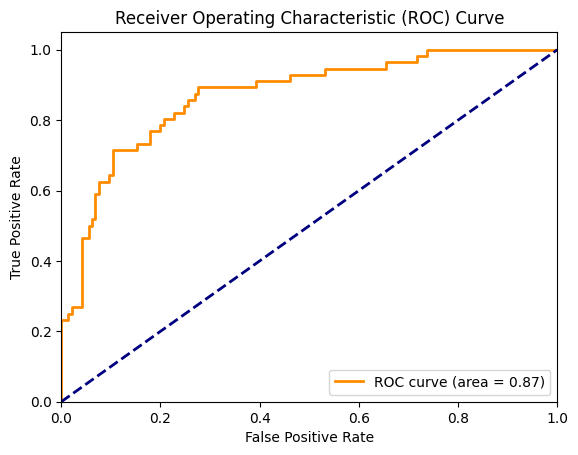

(1001, 59)


In [6]:
import os
import pandas as pd
from google.cloud import bigquery, storage
from google.colab import auth
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve, auc
import matplotlib.pyplot as plt

# Set up environment and authenticate (if running on Colab or GCP)
auth.authenticate_user()
project_id = 'mcxrp-429811'
os.environ["GOOGLE_CLOUD_PROJECT"] = project_id

# Initialize BigQuery and Storage clients
client = bigquery.Client(project=project_id)
storage_client = storage.Client(project=project_id)

# Bucket and data paths
bucket_name = 'cxr_embedding'
bucket = storage_client.bucket(bucket_name)

# Load the significant_df_filtered.csv file
sig_df_blob = bucket.blob('significant_df_filtered.csv')
sig_df_blob.download_to_filename('/tmp/significant_df_filtered.csv')
significant_df_filtered = pd.read_csv('/tmp/significant_df_filtered.csv')

# Extract column names from the 2nd row onward in significant_df_filtered
selected_columns = significant_df_filtered['Column'].iloc[:].tolist()

# Ensure avg_mbp and avg_mbp_ni are included for combining
if 'avg_mbp' not in selected_columns:
    selected_columns.append('avg_mbp')
if 'avg_mbp_ni' not in selected_columns:
    selected_columns.append('avg_mbp_ni')

# Filter the ARDS cohort DataFrame to include only the selected columns
selected_columns_with_target = selected_columns + ['icu_mort']
ards_df_filtered = ards_df[selected_columns_with_target]

# Combine avg_mbp and avg_mbp_ni into a new column final_avg_mbp
ards_df_filtered['final_avg_mbp'] = ards_df_filtered['avg_mbp'].combine_first(ards_df_filtered['avg_mbp_ni'])

# Drop the original avg_mbp and avg_mbp_ni columns
ards_df_filtered = ards_df_filtered.drop(columns=['avg_mbp', 'avg_mbp_ni'])

# Define X (features) and y (target)
X = ards_df_filtered.drop(columns=['icu_mort'])
y = ards_df_filtered['icu_mort']

# Split the data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Initialize the XGBoost model
xgb_model = xgb.XGBClassifier(eval_metric='logloss', n_estimators=100, max_depth=4)

# Train the model on the full training data
xgb_model.fit(X_train, y_train)

# Predict probabilities on the test set
y_pred_prob = xgb_model.predict_proba(X_test)[:, 1]

# Calculate the AUROC score on the test set
auroc = roc_auc_score(y_test, y_pred_prob)
print(f'Test AUROC: {auroc}')

# Plot the ROC curve
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

print(X.shape)

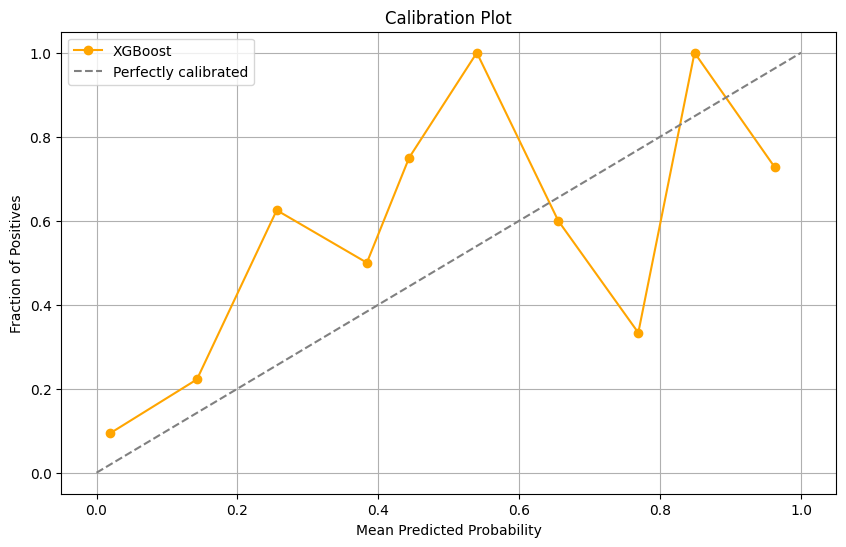

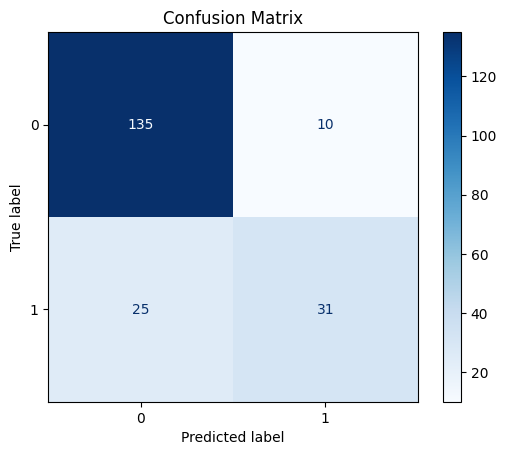

In [7]:
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Step 5: Calibration plot
plt.figure(figsize=(10, 6))

# Calibration curve
prob_true, prob_pred = calibration_curve(y_test, y_pred_prob, n_bins=10)
plt.plot(prob_pred, prob_true, marker='o', color='orange', label='XGBoost')

# Plot the perfect calibration line
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfectly calibrated')

plt.title('Calibration Plot')
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Positives')
plt.legend()
plt.grid()
plt.show()

# Step 6: Confusion matrix
y_pred = (y_pred_prob >= 0.5).astype(int)  # Binarize predictions based on 0.5 threshold
conf_matrix = confusion_matrix(y_test, y_pred)

# Plot confusion matrix
ConfusionMatrixDisplay(confusion_matrix=conf_matrix).plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

In [8]:
from google.cloud import storage
import pandas as pd

# Assuming X is already defined as a DataFrame

# Save X to a CSV file locally
X.to_csv('/tmp/X.csv', index=False)

# Set up the Google Cloud Storage client
storage_client = storage.Client()
bucket_name = 'cxr_embedding'
bucket = storage_client.bucket(bucket_name)

# Upload the CSV file to the GCP bucket
blob = bucket.blob('X.csv')
blob.upload_from_filename('/tmp/X.csv')

print(f'File X.csv has been uploaded to the bucket {bucket_name}.')


File X.csv has been uploaded to the bucket cxr_embedding.


# Colinear Covariance to filter out columns with equal contributions, then undergo AUROC

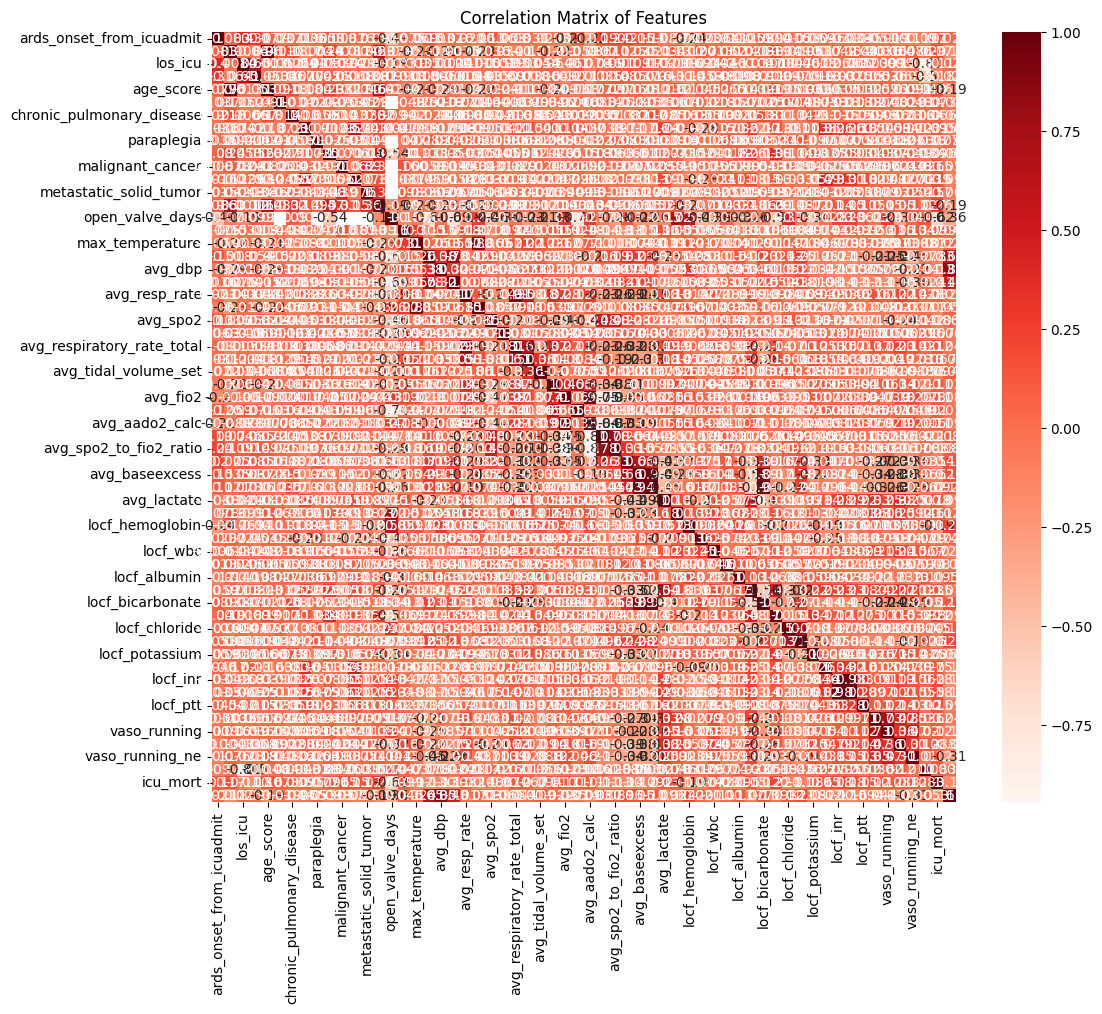

Variance Inflation Factor (VIF):
                          Feature           VIF
0        ards_onset_from_icuadmit      2.214529
1                   admission_age    217.624714
2                         los_icu     16.676117
3                    los_hospital      4.791146
4                       age_score     67.199301
5                        dementia      1.096111
6       chronic_pulmonary_disease      2.203805
7              mild_liver_disease      2.427385
8                      paraplegia      1.288919
9                   renal_disease      2.723494
10               malignant_cancer      1.869299
11           severe_liver_disease      2.425753
12         metastatic_solid_tumor      1.939778
13     charlson_comorbidity_index     26.158506
14                open_valve_days      7.456197
15                 max_heart_rate     34.865832
16                max_temperature   9423.552727
17                        avg_sbp    273.737062
18                        avg_dbp    226.713828
19     

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.10/dist-packages/matplotlib/pyplot.py'>

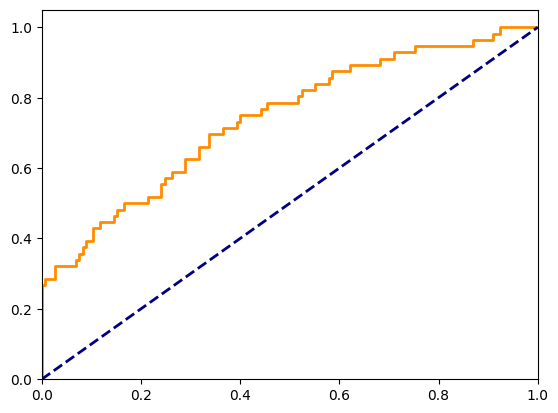

In [9]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve, auc
from statsmodels.stats.outliers_influence import variance_inflation_factor
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming the ards_df_filtered DataFrame is already created and processed

# Step 1: Calculate the Correlation Matrix
correlation_matrix = ards_df_filtered.corr()

# Display the correlation matrix
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap=plt.cm.Reds)
plt.title("Correlation Matrix of Features")
plt.show()

# Step 2: Calculate VIF (Variance Inflation Factor)
X_vif = ards_df_filtered.drop(columns=['icu_mort'])

# Handle infinite and missing values before calculating VIF
X_vif_no_inf = X_vif.replace([np.inf, -np.inf], np.nan) # Replace infinite values with NaN
X_vif_no_missing = X_vif_no_inf.fillna(X_vif_no_inf.mean()) # Impute missing values using the mean

# Calculate VIF for each feature
vif_data = pd.DataFrame()
vif_data["Feature"] = X_vif_no_missing.columns # Assign column names to 'Feature' column
vif_data["VIF"] = [variance_inflation_factor(X_vif_no_missing.values, i) for i in range(X_vif_no_missing.shape[1])]

# Display VIF values
print("Variance Inflation Factor (VIF):")
print(vif_data)

# Step 3: Remove Highly Collinear Features
# Define a threshold for correlation and VIF (e.g., 0.9 for correlation, 10 for VIF)
correlation_threshold = 0.9
vif_threshold = 10

# Identify features to drop based on correlation
high_correlation_pairs = correlation_matrix[(correlation_matrix > correlation_threshold) & (correlation_matrix != 1.0)]
features_to_drop = set()

for column in high_correlation_pairs.columns:
    if any(high_correlation_pairs[column] > correlation_threshold):
        features_to_drop.add(column)

# Identify features to drop based on VIF
features_to_drop.update(vif_data[vif_data["VIF"] > vif_threshold]["Feature"])

# Drop identified features from the dataset
X_filtered = X_vif.drop(columns=list(features_to_drop))
print(f"Features dropped due to high collinearity: {features_to_drop}")


# Remove the 'open_valve_days' column from X_filtered if it exists
if 'open_valve_days' in X_filtered.columns:
    X_filtered = X_filtered.drop(columns=['open_valve_days'])
    print("Column 'open_valve_days' removed from X_filtered.")
else:
    print("Column 'open_valve_days' not found in X_filtered.")

# Step 4: Retrain the XGBoost Model with the filtered features
y = ards_df_filtered['icu_mort']
X_train, X_test, y_train, y_test = train_test_split(X_filtered, y, test_size=0.2, random_state=42, stratify=y)

xgb_model = xgb.XGBClassifier(eval_metric='logloss', n_estimators=100, max_depth=4)
xgb_model.fit(X_train, y_train)

y_pred_prob = xgb_model.predict_proba(X_test)[:, 1]
auroc = roc_auc_score(y_test, y_pred_prob)
print(f'Test AUROC after removing collinear features: {auroc}')
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt

Feature Correlation Table (sorted by absolute correlation):
                      Feature 1               Feature 2  Correlation
3051                   locf_inr                 locf_pt     0.983843
64                admission_age               age_score     0.961821
1712                   avg_fio2  avg_spo2_to_fio2_ratio     0.944758
2075             avg_baseexcess            avg_totalco2     0.943085
2144               avg_totalco2        locf_bicarbonate     0.938432
...                         ...                     ...          ...
1100                    avg_dbp           avg_resp_rate     0.000406
287                   age_score             locf_sodium     0.000319
1775       avg_driving_pressure            avg_totalco2     0.000248
388   chronic_pulmonary_disease                avg_fio2     0.000166
314                    dementia         open_valve_days          NaN

[1766 rows x 3 columns]


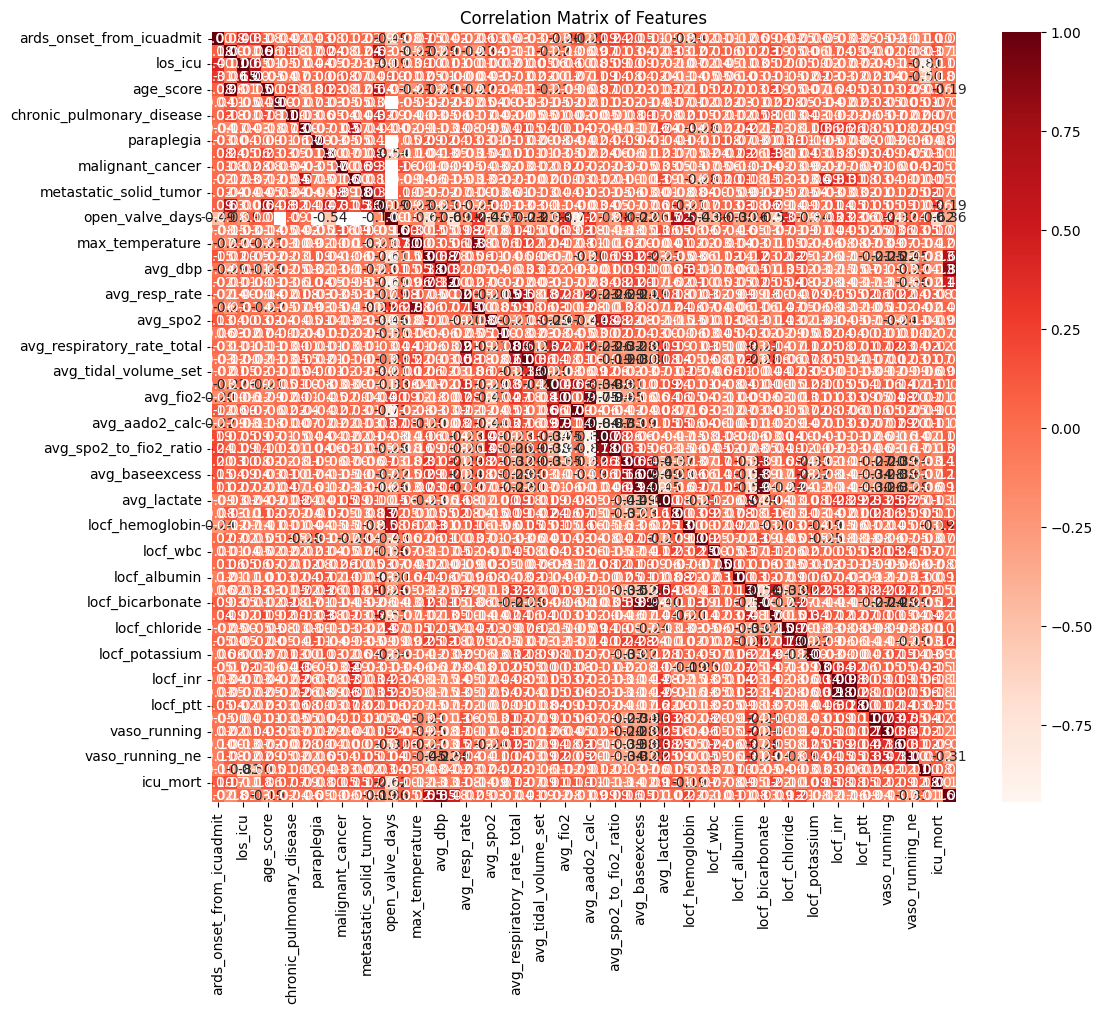

Variance Inflation Factor (VIF):
                          Feature           VIF
0        ards_onset_from_icuadmit      2.214529
1                   admission_age    217.624714
2                         los_icu     16.676117
3                    los_hospital      4.791146
4                       age_score     67.199301
5                        dementia      1.096111
6       chronic_pulmonary_disease      2.203805
7              mild_liver_disease      2.427385
8                      paraplegia      1.288919
9                   renal_disease      2.723494
10               malignant_cancer      1.869299
11           severe_liver_disease      2.425753
12         metastatic_solid_tumor      1.939778
13     charlson_comorbidity_index     26.158506
14                open_valve_days      7.456197
15                 max_heart_rate     34.865832
16                max_temperature   9423.552727
17                        avg_sbp    273.737062
18                        avg_dbp    226.713828
19     

In [13]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve, auc
from statsmodels.stats.outliers_influence import variance_inflation_factor
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming the ards_df_filtered DataFrame is already created and processed

# Step 1: Calculate the Correlation Matrix
correlation_matrix = ards_df_filtered.corr()

# Step 2: Flatten the Correlation Matrix and Create a Table
# Create a DataFrame that lists all pairs of features and their correlation
corr_pairs = correlation_matrix.abs().unstack().reset_index()
corr_pairs.columns = ['Feature 1', 'Feature 2', 'Correlation']
# Remove self-correlations and duplicate pairs
corr_pairs = corr_pairs[corr_pairs['Feature 1'] != corr_pairs['Feature 2']]
corr_pairs = corr_pairs.drop_duplicates(subset=['Correlation'])

# Sort by the absolute value of the correlation
corr_pairs_sorted = corr_pairs.sort_values(by='Correlation', ascending=False)

# Display the table of feature correlations
print("Feature Correlation Table (sorted by absolute correlation):")
print(corr_pairs_sorted)

# Display the Correlation Heatmap for Visual Inspection
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap=plt.cm.Reds, fmt='.2f')
plt.title("Correlation Matrix of Features")
plt.show()

# Continue with VIF calculation and other steps as needed

# Step 3: Calculate VIF (Variance Inflation Factor)
X_vif = ards_df_filtered.drop(columns=['icu_mort'])

# Handle infinite and missing values before calculating VIF
X_vif_no_inf = X_vif.replace([np.inf, -np.inf], np.nan)  # Replace infinite values with NaN
X_vif_no_missing = X_vif_no_inf.fillna(X_vif_no_inf.mean())  # Impute missing values using the mean

# Calculate VIF for each feature
vif_data = pd.DataFrame()
vif_data["Feature"] = X_vif_no_missing.columns  # Assign column names to 'Feature' column
vif_data["VIF"] = [variance_inflation_factor(X_vif_no_missing.values, i) for i in range(X_vif_no_missing.shape[1])]

# Display VIF values
print("Variance Inflation Factor (VIF):")
print(vif_data)

# Continue with the rest of your steps for feature selection and model training...


In [14]:
from google.cloud import storage
import pandas as pd

# Assuming X is already defined as a DataFrame

# Save X to a CSV file locally
corr_pairs_sorted.to_csv('/tmp/corr_pairs_sorted.csv', index=False)

# Set up the Google Cloud Storage client
storage_client = storage.Client()
bucket_name = 'cxr_embedding'
bucket = storage_client.bucket(bucket_name)

# Upload the CSV file to the GCP bucket
blob = bucket.blob('corr_pairs_sorted.csv')
blob.upload_from_filename('/tmp/corr_pairs_sorted.csv')

print(f'File corr_pairs_sorted.csv has been uploaded to the bucket {bucket_name}.')


File corr_pairs_sorted.csv has been uploaded to the bucket cxr_embedding.


In [10]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_auc_score, roc_curve, auc
from imblearn.over_sampling import SMOTE
from sklearn.feature_selection import RFE
import xgboost as xgb
# Step 4: Retrain the XGBoost Model with the filtered features
y = ards_df_filtered['icu_mort']
X_train, X_test, y_train, y_test = train_test_split(X_filtered, y, test_size=0.2, random_state=42, stratify=y)

# Step 2: Perform Recursive Feature Elimination (RFE)
xgb_temp = xgb.XGBClassifier(eval_metric='logloss', n_estimators=100, max_depth=4)
rfe = RFE(estimator=xgb_temp, n_features_to_select=10)  # Adjust n_features_to_select as needed
X_rfe = rfe.fit_transform(X_filtered, y)

# Step 3: Hyperparameter Tuning with GridSearchCV
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 4, 5],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 0.9, 1.0],
    'colsample_bytree': [0.8, 0.9, 1.0]
}
grid_search = GridSearchCV(estimator=xgb.XGBClassifier(eval_metric='logloss'), param_grid=param_grid, scoring='roc_auc', cv=5, n_jobs=-1)
grid_search.fit(X_filtered, y)

GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False,
                                     eval_metric='logloss', feature_types=None,
                                     gamma=None, grow_policy=None,
                                     importance_type=None,
                                     interaction_constraints=None,
                                     learning_rate=...
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None,
                                     random_state=None, ...),
             n_jobs=-1,
             param_grid={'colsample_bytree': [0.8, 0.9, 1.0],
                         'learning_rate': [0.01, 0.1, 0.2],
                         'max_depth': [3, 4, 5],
                         'n_estimators': [100, 200, 300],
                         'subsample': [0.8, 0.9, 1.0]},
             scoring='roc_auc')

Test AUROC with improved model: 0.7926108374384236


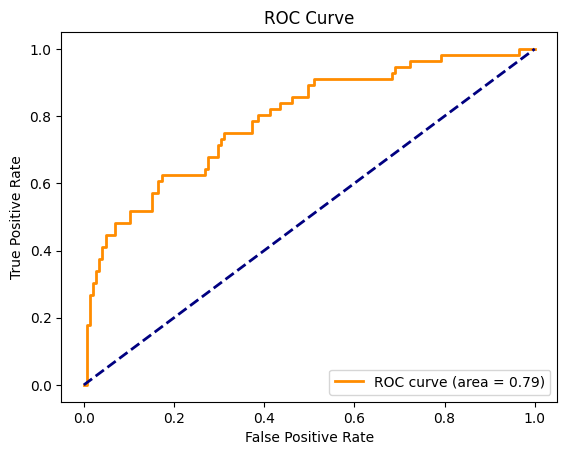

In [73]:
# Step 4: Train the model with the best parameters
best_xgb = grid_search.best_estimator_
best_xgb.fit(X_filtered, y)

# Step 5: Evaluate on Test Set
# Transform the test set using RFE BEFORE training the model
X_train_rfe = rfe.fit_transform(X_train, y_train)
X_test_rfe = rfe.transform(X_test)

# Train the model with the best parameters on the TRANSFORMED training set
best_xgb.fit(X_train_rfe, y_train)

y_pred_prob = best_xgb.predict_proba(X_test_rfe)[:, 1]
auroc = roc_auc_score(y_test, y_pred_prob)
print(f'Test AUROC with improved model: {auroc}')

# Plot ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.show()

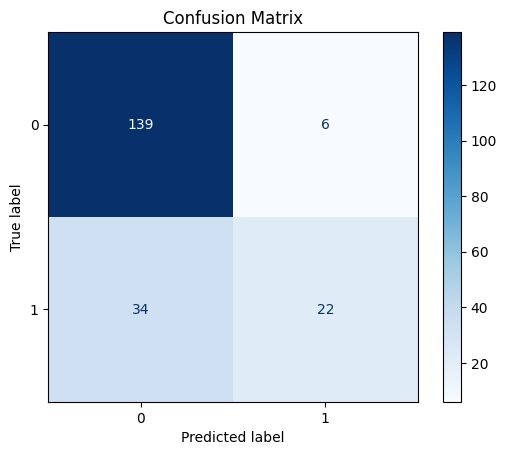

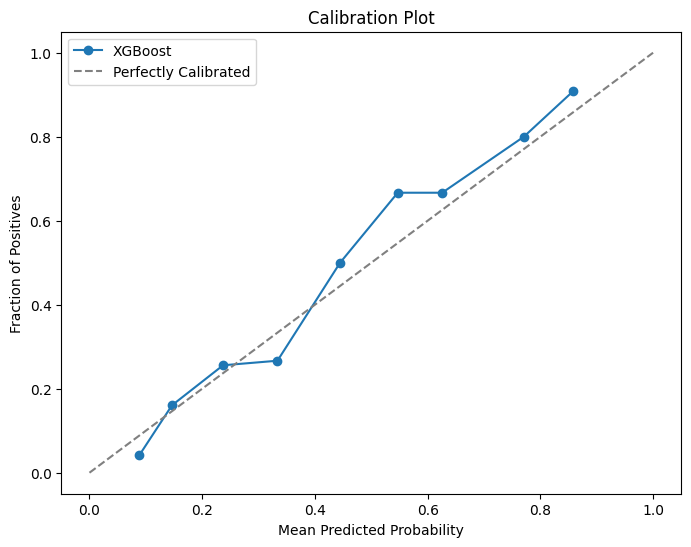

Precision: 0.71
Recall: 0.48
F1 Score: 0.57


In [74]:
# Calibration curvefrom sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, calibration_curve
from sklearn.calibration import CalibrationDisplay
import matplotlib.pyplot as plt
import numpy as np

# Step 1: Generate predictions and the confusion matrix
y_pred = best_xgb.predict(X_test_rfe)
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

# Plot the confusion matrix
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

# Step 2: Calibration Plot
# Generate probability predictions
y_prob = best_xgb.predict_proba(X_test_rfe)[:, 1]

# Calculate calibration curve
prob_true, prob_pred = calibration_curve(y_test, y_prob, n_bins=10)

# Plot calibration curve
plt.figure(figsize=(8, 6))
plt.plot(prob_pred, prob_true, marker='o', label='XGBoost')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfectly Calibrated')
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Positives')
plt.title('Calibration Plot')
plt.legend(loc='best')
plt.show()
# Print precision, recall, and F1-score
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)


print(f'Precision: {precision:.2f}')
print(f'Recall: {recall:.2f}')
print(f'F1 Score: {f1:.2f}')

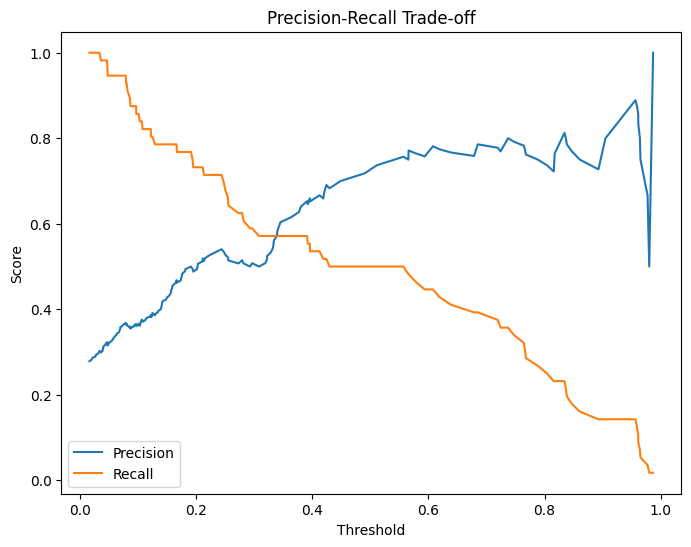

In [99]:
from sklearn.metrics import precision_recall_curve

# Calculate precision-recall pairs for different thresholds
precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob)

# Plot precision and recall as a function of the threshold
plt.figure(figsize=(8, 6))
plt.plot(thresholds, precisions[:-1], label='Precision')
plt.plot(thresholds, recalls[:-1], label='Recall')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision-Recall Trade-off')
plt.legend()
plt.show()

# You can choose a threshold based on this plot or maximize F1 score


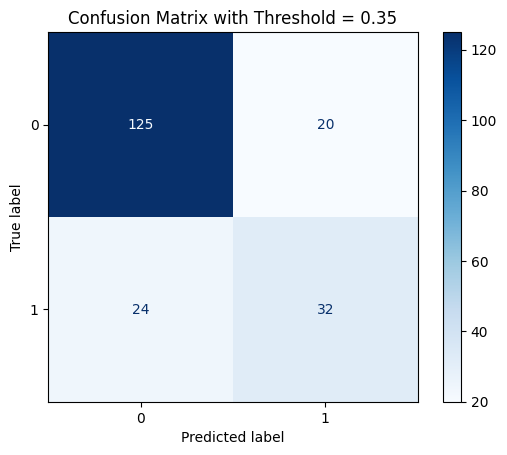

Precision: 0.62
Recall: 0.57
F1 Score: 0.59


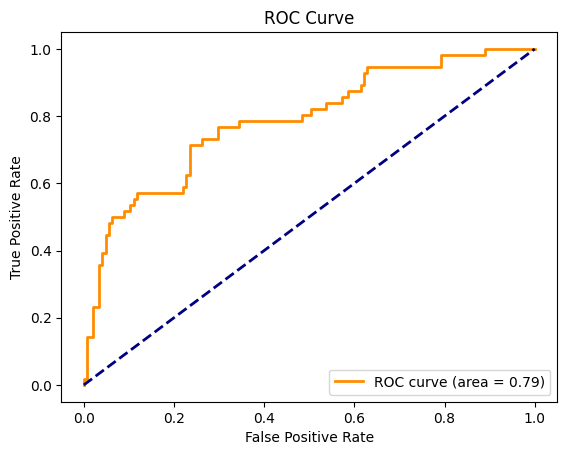

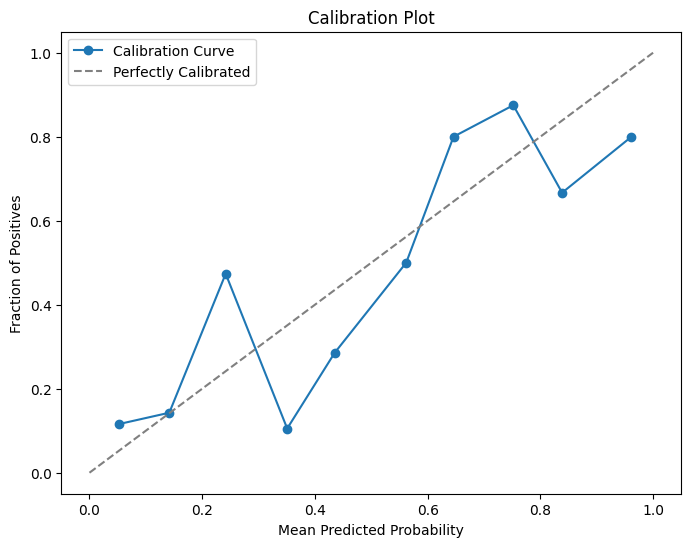

In [107]:
import matplotlib.pyplot as plt
import numpy as np

# Step 1: Predict probabilities on the test set
# Use X_test_rfe (the transformed test set) instead of X_test
y_prob = best_xgb.predict_proba(X_test_rfe)[:, 1]

# Step 2: Set a custom threshold
custom_threshold = 0.35  # Adjust this value based on your needs

# Step 3: Convert probabilities to binary predictions using the custom threshold
y_pred_custom_threshold = (y_prob >= custom_threshold).astype(int)

# Step 4: Evaluate the new predictions
cm = confusion_matrix(y_test, y_pred_custom_threshold)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title(f"Confusion Matrix with Threshold = {custom_threshold}")
plt.show()

# Print precision, recall, and F1-score
precision = precision_score(y_test, y_pred_custom_threshold)
recall = recall_score(y_test, y_pred_custom_threshold)
f1 = f1_score(y_test, y_pred_custom_threshold)

print(f'Precision: {precision:.2f}')
print(f'Recall: {recall:.2f}')
print(f'F1 Score: {f1:.2f}')

# Step 5: Plot the ROC curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.show()

# Step 6: Plot the calibration curve
prob_true, prob_pred = calibration_curve(y_test, y_prob, n_bins=10)
plt.figure(figsize=(8, 6))
plt.plot(prob_pred, prob_true, marker='o', label='Calibration Curve')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfectly Calibrated')
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Positives')
plt.title('Calibration Plot')
plt.legend(loc='best')
plt.show()


In [60]:
from google.cloud import storage
import pandas as pd

# Assuming X is already defined as a DataFrame

# Save X to a CSV file locally
X_filtered.to_csv('/tmp/X_filtered_covariance.csv', index=False)

# Set up the Google Cloud Storage client
storage_client = storage.Client()
bucket_name = 'cxr_embedding'
bucket = storage_client.bucket(bucket_name)

# Upload the CSV file to the GCP bucket
blob = bucket.blob('X_Filtered_covariance.csv')
blob.upload_from_filename('/tmp/X_filtered_covariance.csv')

print(f'File X_filtered_covariance.csv has been uploaded to the bucket {bucket_name}.')


File X_filtered_covariance.csv has been uploaded to the bucket cxr_embedding.


# New Section

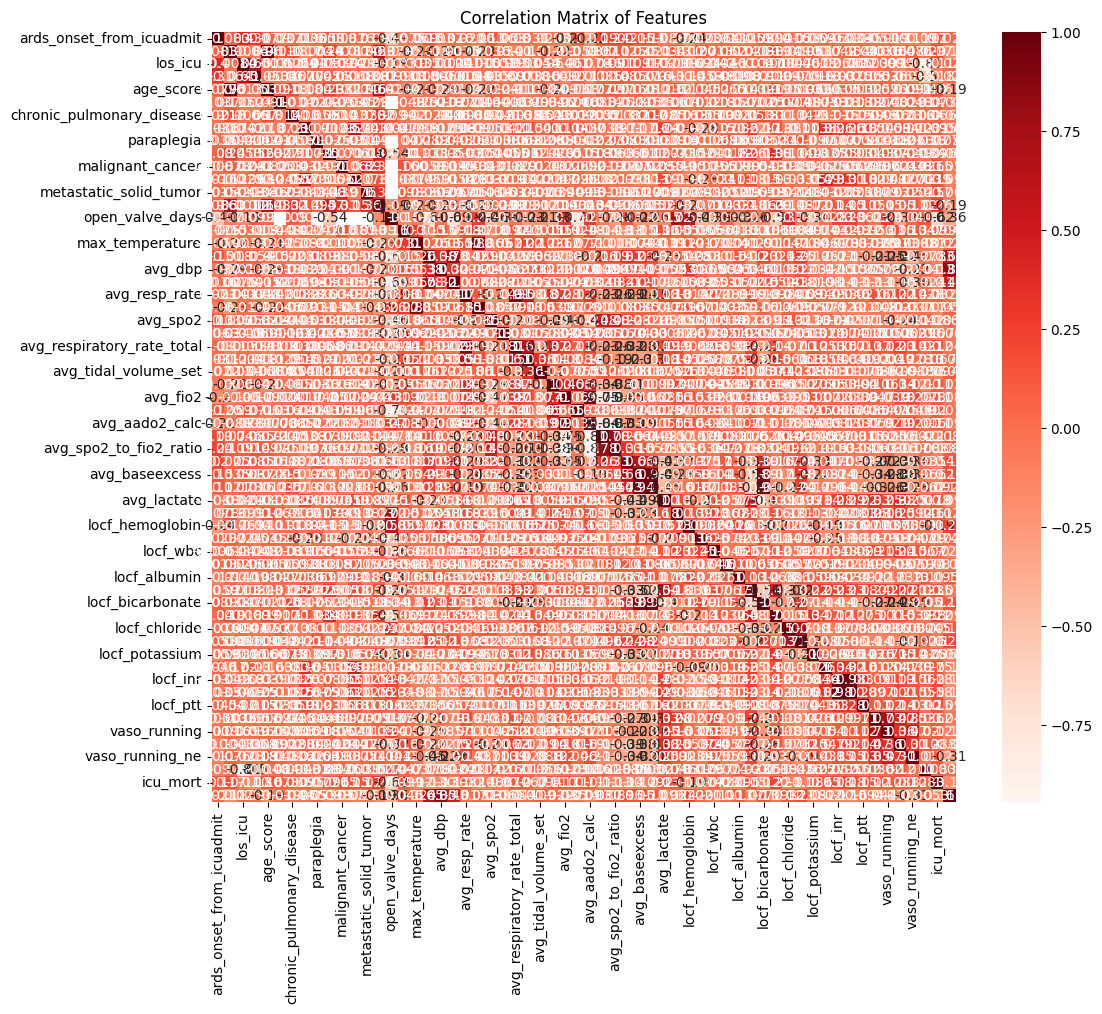

Variance Inflation Factor (VIF):
                          Feature           VIF
0        ards_onset_from_icuadmit      2.214529
1                   admission_age    217.624714
2                         los_icu     16.676117
3                    los_hospital      4.791146
4                       age_score     67.199301
5                        dementia      1.096111
6       chronic_pulmonary_disease      2.203805
7              mild_liver_disease      2.427385
8                      paraplegia      1.288919
9                   renal_disease      2.723494
10               malignant_cancer      1.869299
11           severe_liver_disease      2.425753
12         metastatic_solid_tumor      1.939778
13     charlson_comorbidity_index     26.158506
14                open_valve_days      7.456197
15                 max_heart_rate     34.865832
16                max_temperature   9423.552727
17                        avg_sbp    273.737062
18                        avg_dbp    226.713828
19     

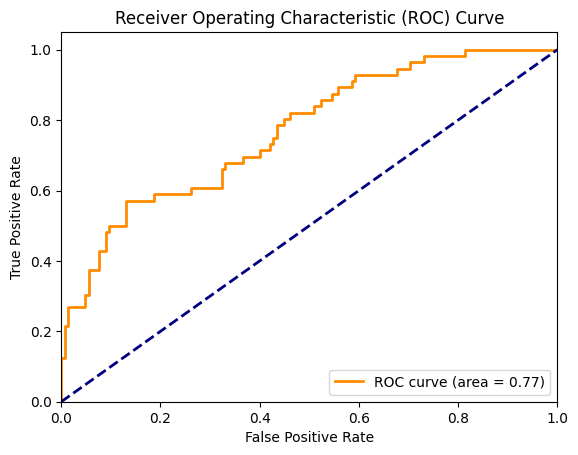

In [97]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve, auc
from statsmodels.stats.outliers_influence import variance_inflation_factor
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming the ards_df_filtered DataFrame is already created and processed

# Step 1: Calculate the Correlation Matrix
correlation_matrix = ards_df_filtered.corr()

# Display the correlation matrix
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap=plt.cm.Reds)
plt.title("Correlation Matrix of Features")
plt.show()

# Step 2: Calculate VIF (Variance Inflation Factor)
X_vif = ards_df_filtered.drop(columns=['icu_mort'])

# Handle infinite and missing values before calculating VIF
X_vif_no_inf = X_vif.replace([np.inf, -np.inf], np.nan)  # Replace infinite values with NaN
X_vif_no_missing = X_vif_no_inf.fillna(X_vif_no_inf.mean())  # Impute missing values using the mean

# Calculate VIF for each feature
vif_data = pd.DataFrame()
vif_data["Feature"] = X_vif_no_missing.columns  # Assign column names to 'Feature' column
vif_data["VIF"] = [variance_inflation_factor(X_vif_no_missing.values, i) for i in range(X_vif_no_missing.shape[1])]

# Display VIF values
print("Variance Inflation Factor (VIF):")
print(vif_data)

# Step 3: Remove Highly Collinear Features
# Define a threshold for correlation and VIF (e.g., 0.9 for correlation, 10 for VIF)
correlation_threshold = 0.9
vif_threshold = 10

# Identify features to drop based on correlation
high_correlation_pairs = correlation_matrix[(correlation_matrix > correlation_threshold) & (correlation_matrix != 1.0)]
features_to_drop = set()

for column in high_correlation_pairs.columns:
    if any(high_correlation_pairs[column] > correlation_threshold):
        features_to_drop.add(column)

# Identify features to drop based on VIF
features_to_drop.update(vif_data[vif_data["VIF"] > vif_threshold]["Feature"])

# Ensure 'admission_age' is included in features to drop if it meets the criteria
if 'admission_age' in X_vif.columns:
    features_to_drop.remove('admission_age')

# Drop identified features from the dataset
X_filtered = X_vif.drop(columns=list(features_to_drop))
print(f"Features dropped due to high collinearity: {features_to_drop}")

# Remove the 'open_valve_days' column from X_filtered if it exists
if 'open_valve_days' in X_filtered.columns:
    X_filtered = X_filtered.drop(columns=['open_valve_days'])
    print("Column 'open_valve_days' removed from X_filtered.")
else:
    print("Column 'open_valve_days' not found in X_filtered.")

# Step 4: Retrain the XGBoost Model with the filtered features
y = ards_df_filtered['icu_mort']
X_train, X_test, y_train, y_test = train_test_split(X_filtered, y, test_size=0.2, random_state=42, stratify=y)

xgb_model = xgb.XGBClassifier(eval_metric='logloss', n_estimators=100, max_depth=4)
xgb_model.fit(X_train, y_train)

y_pred_prob = xgb_model.predict_proba(X_test)[:, 1]
auroc = roc_auc_score(y_test, y_pred_prob)
print(f'Test AUROC after removing collinear features: {auroc}')
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()


Test AUROC with improved model: 0.7874384236453202


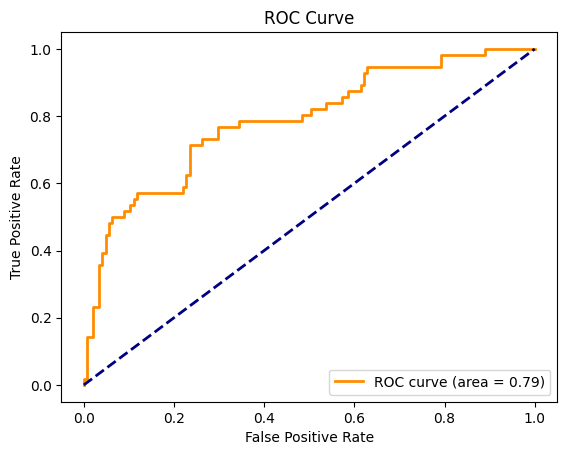

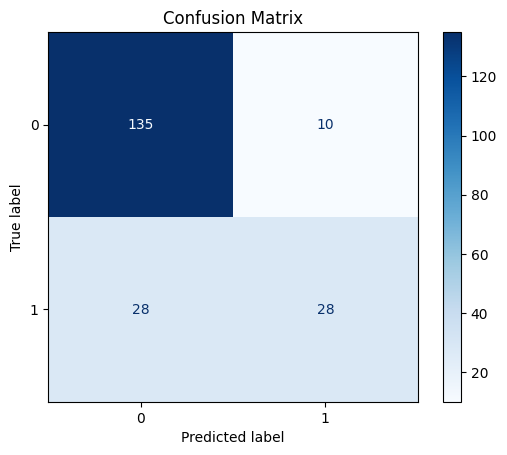

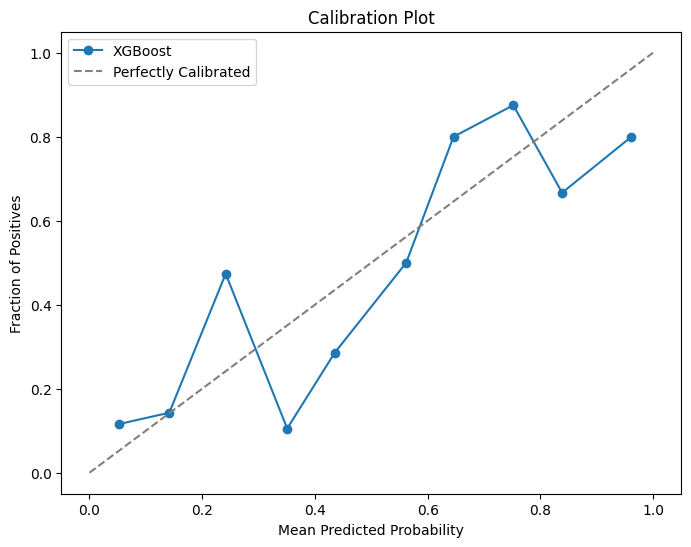

Precision: 0.74
Recall: 0.50
F1 Score: 0.60


In [98]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_auc_score, roc_curve, auc
from imblearn.over_sampling import SMOTE
from sklearn.feature_selection import RFE
import xgboost as xgb
# Step 4: Retrain the XGBoost Model with the filtered features
y = ards_df_filtered['icu_mort']
X_train, X_test, y_train, y_test = train_test_split(X_filtered, y, test_size=0.2, random_state=42, stratify=y)

# Step 2: Perform Recursive Feature Elimination (RFE)
xgb_temp = xgb.XGBClassifier(eval_metric='logloss', n_estimators=100, max_depth=4)
rfe = RFE(estimator=xgb_temp, n_features_to_select=10)  # Adjust n_features_to_select as needed
X_rfe = rfe.fit_transform(X_filtered, y)

# Step 3: Hyperparameter Tuning with GridSearchCV
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 4, 5],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 0.9, 1.0],
    'colsample_bytree': [0.8, 0.9, 1.0]
}
grid_search = GridSearchCV(estimator=xgb.XGBClassifier(eval_metric='logloss'), param_grid=param_grid, scoring='roc_auc', cv=5, n_jobs=-1)
grid_search.fit(X_filtered, y)
# Step 4: Train the model with the best parameters
best_xgb = grid_search.best_estimator_
best_xgb.fit(X_filtered, y)

# Step 5: Evaluate on Test Set
# Transform the test set using RFE BEFORE training the model
X_train_rfe = rfe.fit_transform(X_train, y_train)
X_test_rfe = rfe.transform(X_test)

# Train the model with the best parameters on the TRANSFORMED training set
best_xgb.fit(X_train_rfe, y_train)

y_pred_prob = best_xgb.predict_proba(X_test_rfe)[:, 1]
auroc = roc_auc_score(y_test, y_pred_prob)
print(f'Test AUROC with improved model: {auroc}')

# Plot ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.show()

# Calibration curvefrom sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, calibration_curve
from sklearn.calibration import CalibrationDisplay
import matplotlib.pyplot as plt
import numpy as np

# Step 1: Generate predictions and the confusion matrix
y_pred = best_xgb.predict(X_test_rfe)
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

# Plot the confusion matrix
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

# Step 2: Calibration Plot
# Generate probability predictions
y_prob = best_xgb.predict_proba(X_test_rfe)[:, 1]

# Calculate calibration curve
prob_true, prob_pred = calibration_curve(y_test, y_prob, n_bins=10)

# Plot calibration curve
plt.figure(figsize=(8, 6))
plt.plot(prob_pred, prob_true, marker='o', label='XGBoost')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfectly Calibrated')
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Positives')
plt.title('Calibration Plot')
plt.legend(loc='best')
plt.show()
# Print precision, recall, and F1-score
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)


print(f'Precision: {precision:.2f}')
print(f'Recall: {recall:.2f}')
print(f'F1 Score: {f1:.2f}')

# [W] Weighting biased data

In [61]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import GridSearchCV
from sklearn.calibration import CalibrationDisplay
from sklearn.feature_selection import RFE
import matplotlib.pyplot as plt
import numpy as np
import xgboost as xgb
from sklearn.utils import resample

# Step 1: Perform Recursive Feature Elimination (RFE)
xgb_temp = xgb.XGBClassifier(eval_metric='logloss', n_estimators=100, max_depth=4)
rfe = RFE(estimator=xgb_temp, n_features_to_select=10)  # Adjust n_features_to_select as needed
X_rfe = rfe.fit_transform(X_filtered, y)

# Step 2: Apply SMOTE to balance the classes in the training set
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_rfe, y_train)

# Step 3: Hyperparameter Tuning with GridSearchCV
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 4, 5],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 0.9, 1.0],
    'colsample_bytree': [0.8, 0.9, 1.0]
}
grid_search = GridSearchCV(estimator=xgb.XGBClassifier(eval_metric='logloss'), param_grid=param_grid, scoring='roc_auc', cv=5, n_jobs=1)
grid_search.fit(X_train_smote, y_train_smote)

# Step 4: Train the model with the best parameters on the SMOTE-balanced data
best_xgb = grid_search.best_estimator_
best_xgb.fit(X_train_smote, y_train_smote)

# Step 5: Balance the test set by undersampling the majority class
X_test_majority = X_test_rfe[y_test == 0]
X_test_minority = X_test_rfe[y_test == 1]
y_test_majority = y_test[y_test == 0]
y_test_minority = y_test[y_test == 1]

X_test_majority_downsampled, y_test_majority_downsampled = resample(
    X_test_majority,
    y_test_majority,
    replace=False,  # Sample without replacement
    n_samples=len(y_test_minority),  # Match the number of minority samples
    random_state=42
)

# Combine the downsampled majority class with the minority class
X_test_balanced = np.vstack((X_test_majority_downsampled, X_test_minority))
y_test_balanced = np.hstack((y_test_majority_downsampled, y_test_minority))

# Step 6: Evaluate on the balanced test set
y_pred_prob = best_xgb.predict_proba(X_test_balanced)[:, 1]
auroc = roc_auc_score(y_test_balanced, y_pred_prob)
print(f'Test AUROC with SMOTE-balanced model on balanced test set: {auroc}')

# Plot ROC Curve for the balanced test set
fpr, tpr, _ = roc_curve(y_test_balanced, y_pred_prob)
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve on Balanced Test Set')
plt.legend(loc="lower right")
plt.show()

# Step 7: Confusion Matrix
y_pred = best_xgb.predict(X_test_balanced)
cm = confusion_matrix(y_test_balanced, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix on Balanced Test Set")
plt.show()

# Step 8: Calibration Plot
prob_true, prob_pred = calibration_curve(y_test_balanced, y_pred_prob, n_bins=10)
plt.figure(figsize=(8, 6))
plt.plot(prob_pred, prob_true, marker='o', label='XGBoost (SMOTE)')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfectly Calibrated')
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Positives')
plt.title('Calibration Plot on Balanced Test Set')
plt.legend(loc='best')
plt.show()


KeyboardInterrupt: 

# Change threshold for better result

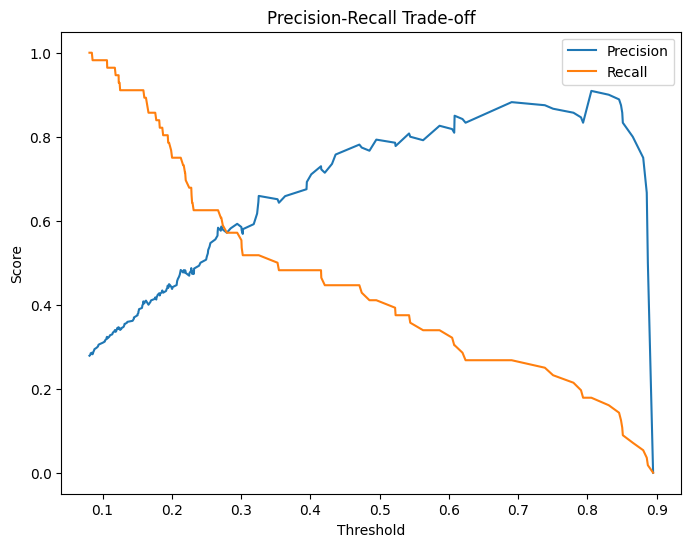

In [ ]:
from sklearn.metrics import precision_recall_curve

# Calculate precision-recall pairs for different thresholds
precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob)

# Plot precision and recall as a function of the threshold
plt.figure(figsize=(8, 6))
plt.plot(thresholds, precisions[:-1], label='Precision')
plt.plot(thresholds, recalls[:-1], label='Recall')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision-Recall Trade-off')
plt.legend()
plt.show()

# You can choose a threshold based on this plot or maximize F1 score


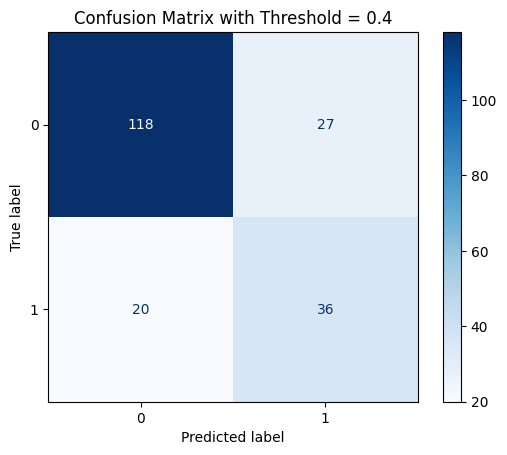

Precision: 0.57
Recall: 0.64
F1 Score: 0.61


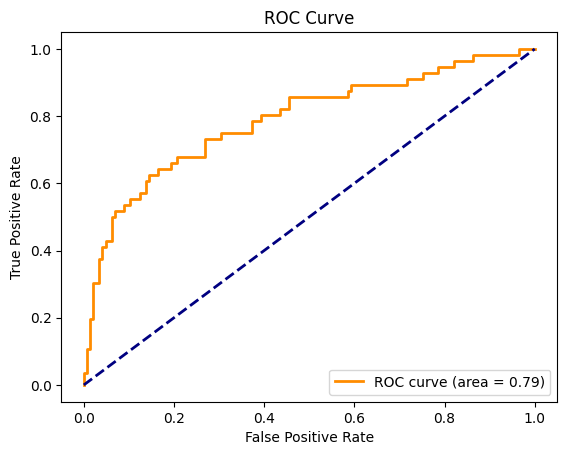

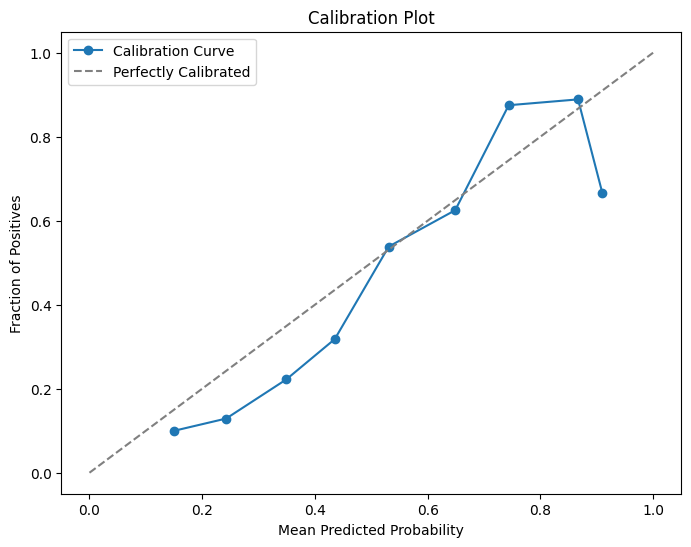

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Step 1: Predict probabilities on the test set
y_prob = best_xgb.predict_proba(X_test_rfe)[:, 1]

# Step 2: Set a custom threshold
custom_threshold = 0.4  # Adjust this value based on your needs

# Step 3: Convert probabilities to binary predictions using the custom threshold
y_pred_custom_threshold = (y_prob >= custom_threshold).astype(int)

# Step 4: Evaluate the new predictions
cm = confusion_matrix(y_test, y_pred_custom_threshold)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title(f"Confusion Matrix with Threshold = {custom_threshold}")
plt.show()

# Print precision, recall, and F1-score
precision = precision_score(y_test, y_pred_custom_threshold)
recall = recall_score(y_test, y_pred_custom_threshold)
f1 = f1_score(y_test, y_pred_custom_threshold)

print(f'Precision: {precision:.2f}')
print(f'Recall: {recall:.2f}')
print(f'F1 Score: {f1:.2f}')

# Step 5: Plot the ROC curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.show()

# Step 6: Plot the calibration curve
prob_true, prob_pred = calibration_curve(y_test, y_prob, n_bins=10)
plt.figure(figsize=(8, 6))
plt.plot(prob_pred, prob_true, marker='o', label='Calibration Curve')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfectly Calibrated')
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Positives')
plt.title('Calibration Plot')
plt.legend(loc='best')
plt.show()


# light GBM instead of XG boost

[LightGBM] [Info] Number of positive: 279, number of negative: 722
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000323 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2253
[LightGBM] [Info] Number of data points in the train set: 1001, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.278721 -> initscore=-0.950813
[LightGBM] [Info] Start training from score -0.950813
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -i

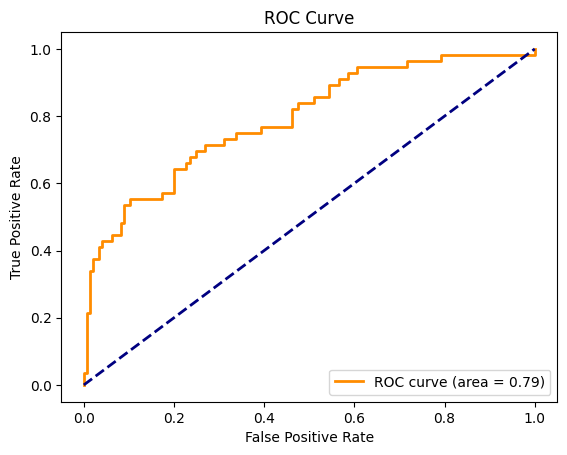

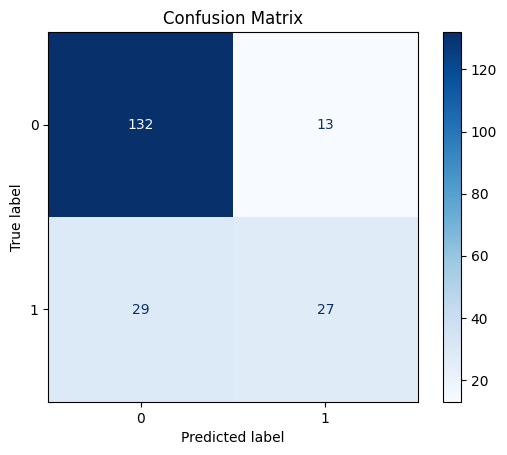

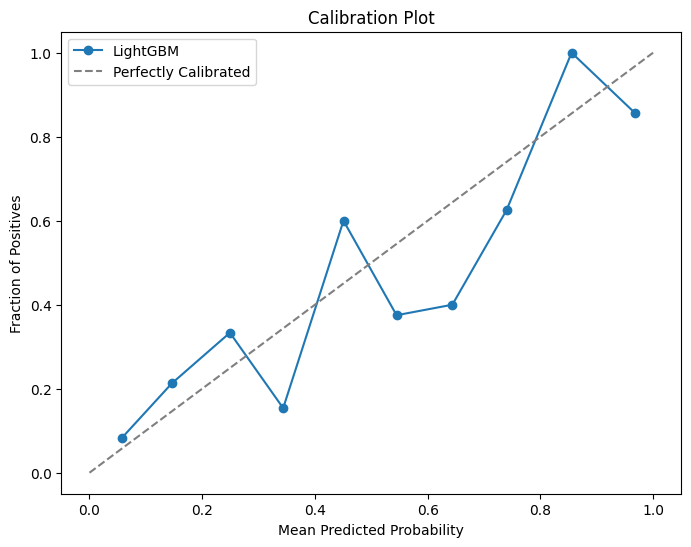

In [80]:
from lightgbm import LGBMClassifier
from sklearn.model_selection import GridSearchCV
from imblearn.over_sampling import SMOTE
from sklearn.feature_selection import RFE
import matplotlib.pyplot as plt
import numpy as np
# Step 4: Retrain the XGBoost Model with the filtered features
y = ards_df_filtered['icu_mort']
X_train, X_test, y_train, y_test = train_test_split(X_filtered, y, test_size=0.2, random_state=42, stratify=y)

# Step 1: Perform Recursive Feature Elimination (RFE)
#lgb_temp = LGBMClassifier(n_estimators=100, max_depth=4)
#rfe = RFE(estimator=lgb_temp, n_features_to_select=10)  # Adjust n_features_to_select as needed
#X_rfe = rfe.fit_transform(X_filtered, y)

# Step 2: Apply SMOTE to balance the classes in the training set
#smote = SMOTE(random_state=42)
#X_train_smote, y_train_smote = smote.fit_resample(X_rfe, y)

# Step 3: Hyperparameter Tuning with GridSearchCV
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 4, 5],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 0.9, 1.0],
    'colsample_bytree': [0.8, 0.9, 1.0]  # LightGBM uses 'colsample_bytree' instead of 'subsample'
}
grid_search = GridSearchCV(estimator=LGBMClassifier(), param_grid=param_grid, scoring='roc_auc', cv=5, n_jobs=-1)
#grid_search.fit(X_rfe, y_train_smote)
grid_search.fit(X_filtered, y)

# Step 4: Train the model with the best parameters
best_lgbm = grid_search.best_estimator_
# Fit the model on the RFE transformed training data
best_lgbm.fit(X_train_rfe, y_train)  # Change this line

# Step 5: Evaluate on the test set
# (No changes required here)
X_test_rfe = rfe.transform(X_test)

# Train the model with the best parameters on the TRANSFORMED training set
y_pred_prob = best_lgbm.predict_proba(X_test_rfe)[:, 1]
auroc = roc_auc_score(y_test, y_pred_prob)
print(f'Test AUROC with LightGBM model: {auroc}')

# Plot ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.show()

# Confusion Matrix
y_pred = best_lgbm.predict(X_test_rfe)
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

# Calibration Plot
prob_true, prob_pred = calibration_curve(y_test, y_pred_prob, n_bins=10)
plt.figure(figsize=(8, 6))
plt.plot(prob_pred, prob_true, marker='o', label='LightGBM')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfectly Calibrated')
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Positives')
plt.title('Calibration Plot')
plt.legend(loc='best')
plt.show()


In [81]:
from sklearn.metrics import precision_score, recall_score, f1_score
# Calculate precision, recall, and F1 score
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Output precision, recall, and F1 score
print(f'Precision: {precision:.2f}')
print(f'Recall: {recall:.2f}')
print(f'F1 Score: {f1:.2f}')


Precision: 0.68
Recall: 0.48
F1 Score: 0.56


# PSO to optimize parameters for XGB model

Stopping search: maximum iterations reached --> 50
Best parameters found: [3.00000000e+02 8.64352090e+00 1.72947102e-01]
Best ROC AUC score: 0.8136743900776885


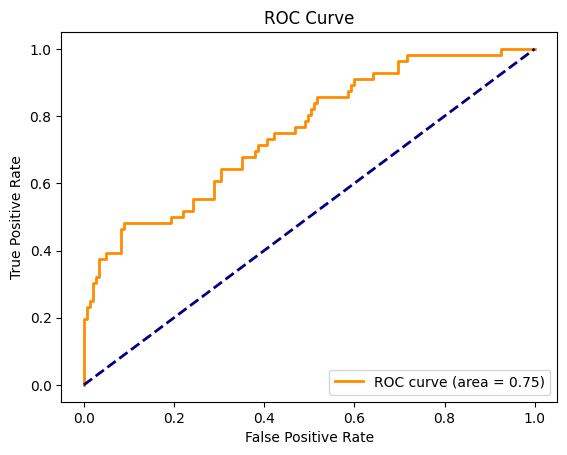

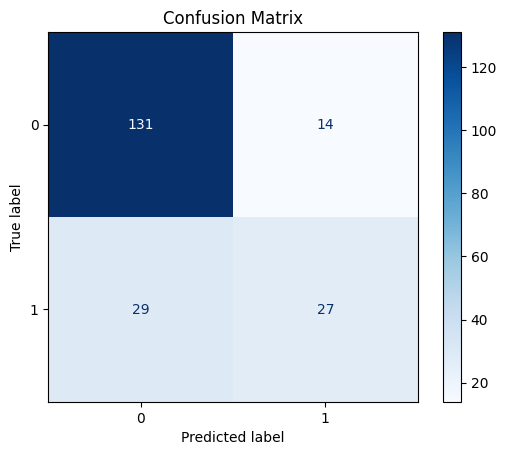

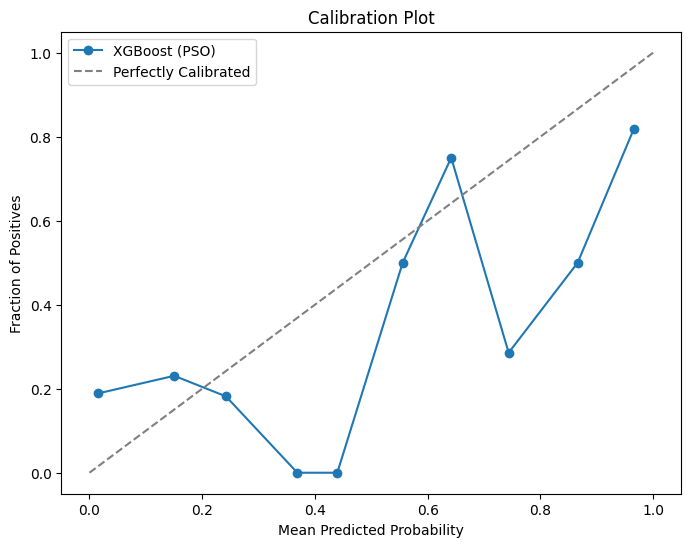

Test AUROC with PSO-optimized model: 0.7535714285714287


In [86]:
from pyswarm import pso
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score, train_test_split
import matplotlib.pyplot as plt
import numpy as np

# Step 1: Define the objective function for PSO
def objective_function(params):
    n_estimators = int(params[0])
    max_depth = int(params[1])
    learning_rate = params[2]

    model = XGBClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        learning_rate=learning_rate,
        eval_metric='logloss'
    )

    # Perform cross-validation on training data only
    score = cross_val_score(model, X_train, y_train, cv=5, scoring='roc_auc').mean()
    return -score  # Minimize negative AUC, so maximizing AUC

# Step 2: Define the search space for PSO
bounds = [
    (50, 300),    # n_estimators
    (3, 10),      # max_depth
    (0.01, 0.3)   # learning_rate
]

# Step 3: Split data into training and test sets
y = ards_df_filtered['icu_mort']
X_train, X_test, y_train, y_test = train_test_split(X_filtered, y, test_size=0.2, random_state=42, stratify=y)

# Step 4: Run PSO optimization
best_params, best_score = pso(objective_function, lb=[b[0] for b in bounds], ub=[b[1] for b in bounds], swarmsize=20, maxiter=50)
print(f"Best parameters found: {best_params}")
print(f"Best ROC AUC score: {-best_score}")

# Step 5: Train the XGBoost model using the best parameters found by PSO
best_xgb = XGBClassifier(
    n_estimators=int(best_params[0]),
    max_depth=int(best_params[1]),
    learning_rate=best_params[2],
    eval_metric='logloss'
)
best_xgb.fit(X_train, y_train)

# Step 6: Evaluate on the test set
y_pred_prob = best_xgb.predict_proba(X_test)[:, 1]
y_pred = best_xgb.predict(X_test)
auroc = roc_auc_score(y_test, y_pred_prob)

# Output AUROC
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.show()

# Output Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

# Output Calibration Plot
prob_true, prob_pred = calibration_curve(y_test, y_pred_prob, n_bins=10)
plt.figure(figsize=(8, 6))
plt.plot(prob_pred, prob_true, marker='o', label='XGBoost (PSO)')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfectly Calibrated')
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Positives')
plt.title('Calibration Plot')
plt.legend(loc='best')
plt.show()

# Print final AUROC score
print(f'Test AUROC with PSO-optimized model: {auroc}')


In [88]:
from sklearn.metrics import precision_score, recall_score, f1_score
# Calculate precision, recall, and F1 score
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Output precision, recall, and F1 score
print(f'Precision: {precision:.2f}')
print(f'Recall: {recall:.2f}')
print(f'F1 Score: {f1:.2f}')


Precision: 0.66
Recall: 0.48
F1 Score: 0.56


# PSO for logistic regression model

Stopping search: maximum iterations reached --> 50
Best parameters found: [0.72962028 0.7265729 ]
Best ROC AUC score: 0.7695876834310118
Precision: 0.51
Recall: 0.64
F1 Score: 0.57
Test AUROC with PSO-optimized model: 0.79


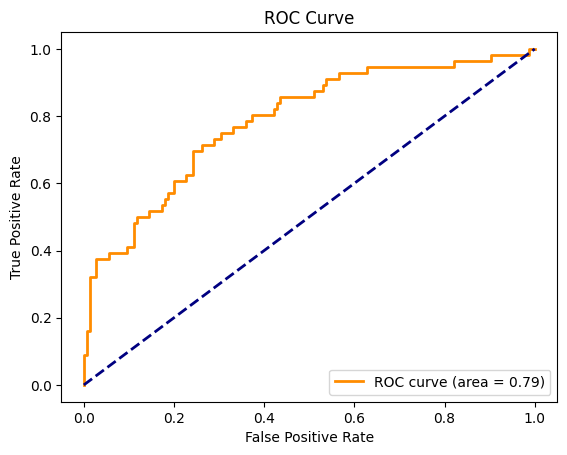

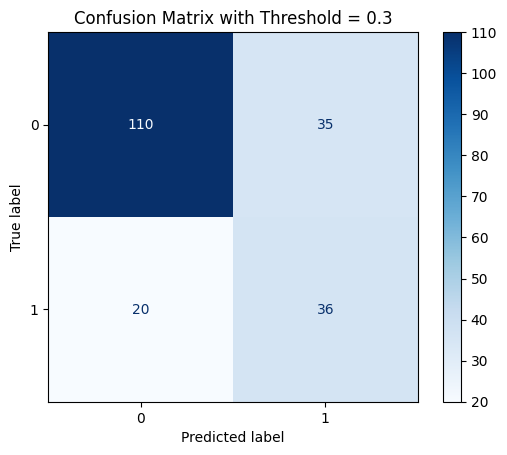

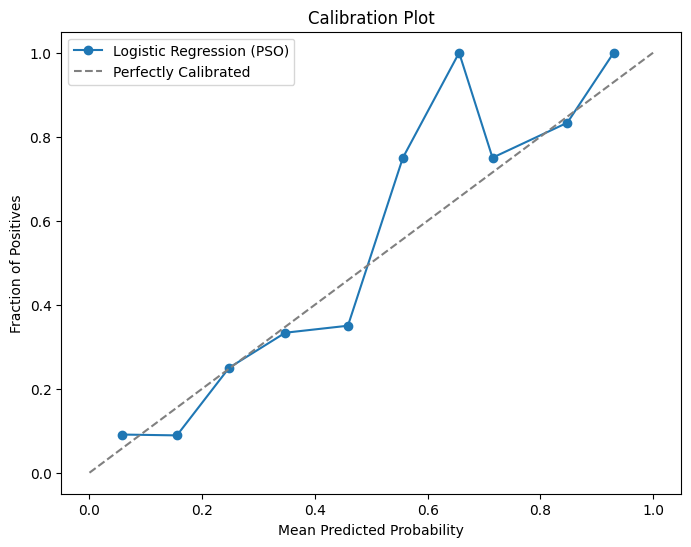

In [85]:
from pyswarm import pso
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.metrics import roc_auc_score, roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay, precision_score, recall_score, f1_score
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt
import numpy as np

# Step 1: Define the objective function for PSO
def objective_function(params):
    C = params[0]
    penalty = 'l2' if params[1] > 0.5 else 'l1'

    model = LogisticRegression(
        C=C,
        penalty=penalty,
        solver='liblinear',
        max_iter=1000,
        random_state=42
    )

    imputer = SimpleImputer(strategy='mean')
    X_train_imputed = imputer.fit_transform(X_train)

    score = cross_val_score(model, X_train_imputed, y_train, cv=5, scoring='roc_auc').mean()
    return -score

# Step 2: Define the search space for PSO
bounds = [
    (0.0001, 10),
    (0, 1)
]

# Step 3: Split data into training and test sets
y = ards_df_filtered['icu_mort']
X_train, X_test, y_train, y_test = train_test_split(X_filtered, y, test_size=0.2, random_state=42, stratify=y)

# Step 4: Run PSO optimization
best_params, best_score = pso(objective_function, lb=[b[0] for b in bounds], ub=[b[1] for b in bounds], swarmsize=20, maxiter=50)
print(f"Best parameters found: {best_params}")
print(f"Best ROC AUC score: {-best_score}")

# Step 5: Train the Logistic Regression model using the best parameters found by PSO
best_penalty = 'l2' if best_params[1] > 0.5 else 'l1'
best_lr = LogisticRegression(
    C=best_params[0],
    penalty=best_penalty,
    solver='liblinear',
    max_iter=1000,
    random_state=42
)

imputer = SimpleImputer(strategy='mean')
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

best_lr.fit(X_train_imputed, y_train)

# Step 6: Evaluate on the test set
y_pred_prob = best_lr.predict_proba(X_test_imputed)[:, 1]

# Set a custom threshold
custom_threshold = 0.3  # You can adjust this value
y_pred_custom_threshold = (y_pred_prob >= custom_threshold).astype(int)

# Evaluate metrics with the custom threshold
precision = precision_score(y_test, y_pred_custom_threshold)
recall = recall_score(y_test, y_pred_custom_threshold)
f1 = f1_score(y_test, y_pred_custom_threshold)
auroc = roc_auc_score(y_test, y_pred_prob)

# Print metrics
print(f'Precision: {precision:.2f}')
print(f'Recall: {recall:.2f}')
print(f'F1 Score: {f1:.2f}')
print(f'Test AUROC with PSO-optimized model: {auroc:.2f}')

# Output AUROC curve
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.show()

# Output Confusion Matrix with custom threshold
cm = confusion_matrix(y_test, y_pred_custom_threshold)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title(f"Confusion Matrix with Threshold = {custom_threshold}")
plt.show()

# Output Calibration Plot
prob_true, prob_pred = calibration_curve(y_test, y_pred_prob, n_bins=10)
plt.figure(figsize=(8, 6))
plt.plot(prob_pred, prob_true, marker='o', label='Logistic Regression (PSO)')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfectly Calibrated')
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Positives')
plt.title('Calibration Plot')
plt.legend(loc='best')
plt.show()


In [78]:
from sklearn.metrics import precision_score, recall_score, f1_score
# Calculate precision, recall, and F1 score
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Output precision, recall, and F1 score
print(f'Precision: {precision:.2f}')
print(f'Recall: {recall:.2f}')
print(f'F1 Score: {f1:.2f}')


Precision: 0.80
Recall: 0.36
F1 Score: 0.49


# Filtered by Dominic


In [15]:
import os
import pandas as pd
from google.cloud import bigquery, storage
from google.colab import auth
# Set up environment and authenticate (if running on Colab or GCP)
auth.authenticate_user()
project_id = 'mcxrp-429811'
os.environ["GOOGLE_CLOUD_PROJECT"] = project_id
# !gcloud config set project {project_id}

# Initialize BigQuery and Storage clients
client = bigquery.Client(project=project_id)
storage_client = storage.Client(project=project_id)

# Bucket and data paths
bucket_name = 'cxr_embedding'
bucket = storage_client.bucket(bucket_name)
ards_data_path = 'X_final.csv'  # Update this path if necessary

# Download the ARDS cohort data file from the GCP bucket
ards_blob = bucket.blob(ards_data_path)
ards_blob.download_to_filename('/tmp/X_final.csv')

# Load the ARDS cohort data into a DataFrame
X = pd.read_csv('/tmp/X_final.csv')

Test AUROC with improved model: 0.6899014778325122


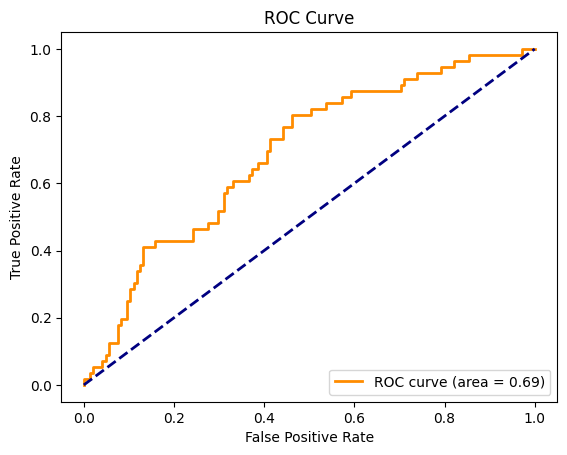

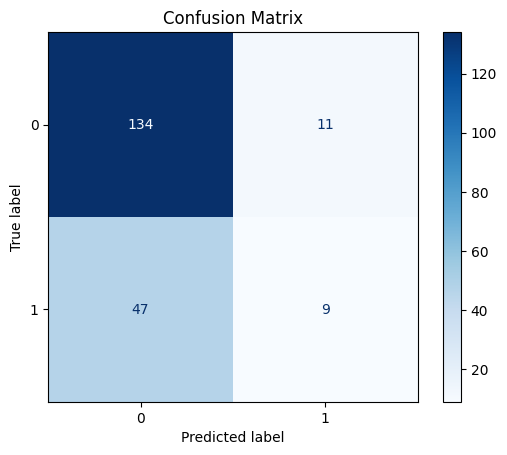

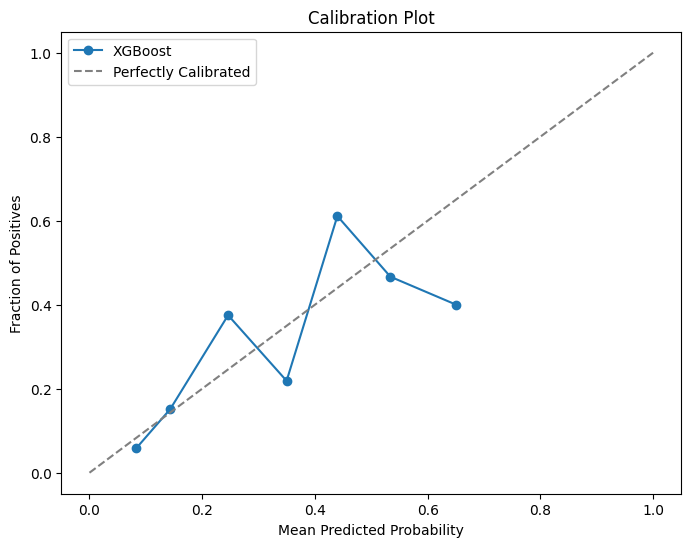

Precision: 0.45
Recall: 0.16
F1 Score: 0.24


In [17]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay, precision_score, recall_score, f1_score
from imblearn.over_sampling import SMOTE
from sklearn.feature_selection import RFE
import xgboost as xgb
import matplotlib.pyplot as plt
import numpy as np

# Assuming y is still defined as before
y = ards_df_filtered['icu_mort']

# Step 1: Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Step 2: Perform Recursive Feature Elimination (RFE)
xgb_temp = xgb.XGBClassifier(eval_metric='logloss', n_estimators=100, max_depth=4)
rfe = RFE(estimator=xgb_temp, n_features_to_select=10)  # Adjust n_features_to_select as needed
X_rfe = rfe.fit_transform(X, y)

# Step 3: Hyperparameter Tuning with GridSearchCV
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 4, 5],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 0.9, 1.0],
    'colsample_bytree': [0.8, 0.9, 1.0]
}
grid_search = GridSearchCV(estimator=xgb.XGBClassifier(eval_metric='logloss'), param_grid=param_grid, scoring='roc_auc', cv=5, n_jobs=-1)
grid_search.fit(X, y)

# Step 4: Train the model with the best parameters
best_xgb = grid_search.best_estimator_
best_xgb.fit(X, y)

# Step 5: Evaluate on Test Set
X_train_rfe = rfe.fit_transform(X_train, y_train)
X_test_rfe = rfe.transform(X_test)
best_xgb.fit(X_train_rfe, y_train)

y_pred_prob = best_xgb.predict_proba(X_test_rfe)[:, 1]
auroc = roc_auc_score(y_test, y_pred_prob)
print(f'Test AUROC with improved model: {auroc}')

# Plot ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.show()

# Confusion Matrix
y_pred = best_xgb.predict(X_test_rfe)
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

# Calibration Plot
y_prob = best_xgb.predict_proba(X_test_rfe)[:, 1]
prob_true, prob_pred = calibration_curve(y_test, y_prob, n_bins=10)
plt.figure(figsize=(8, 6))
plt.plot(prob_pred, prob_true, marker='o', label='XGBoost')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfectly Calibrated')
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Positives')
plt.title('Calibration Plot')
plt.legend(loc='best')
plt.show()

# Print precision, recall, and F1-score
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
print(f'Precision: {precision:.2f}')
print(f'Recall: {recall:.2f}')
print(f'F1 Score: {f1:.2f}')
